<h3><b>GROUP: FEMBOY , BSIT 3C </b> <br><br> </h3>
<b>MEMBERS:</b> <br>
Brucelo, Alyssa Mae B.<br>
Ebuenga, Kristel Ann B.<br>
Fenis, Austin B.<br>
Marfil, John Marvin G.<br>

Project Title: Crime Incident Pattern Analysis
SDG: SDG 16 – Peace and Justice

Objectives:

*  Identifying high-crime areas using spatial clustering
*  Trend analysis of crime type frequency over time

**KAGGLE LINK OF DATASET USED:** <Br> https://www.kaggle.com/datasets/venkatsairo4899/los-angeles-crime-data-2020-2023?select=Crime_Data_from_2020_to_Present.csv

**ADDITIONAL RESOURCES:** <br>
https://catalog.data.gov/dataset/crime-data-from-2020-to-present <Br>
https://greatdata.com/info/currenttime <Br>
https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-2024/2nrs-mtv8/about_data




**1.O INITIALIZATION AND IMPORTING**




In [ ]:
#1.1 PYSPARK
!pip install pyspark

In [ ]:
#1.2 IMPORTS AND INITIALIZATION (adjust if needed sa part niyo)

#MOUNT DRIVE FOR DATASET
from google.colab import drive
drive.mount('/content/drive')

#FOR PYSPARK
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField,
                               StringType, IntegerType,
                               FloatType, DoubleType)

#FOR THE VISUALIZATION (EDA)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

#PLOT STYLING (EDA), PLEASE ADJUST IF NEEDED (FOR MEM 2 AND 4)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

print('Everything is going well!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Everything is going well!


In [ ]:
#1.3 SPARK SESSION

spark = (
    SparkSession.builder.appName('BSIT3C_FEMBOY_WEEK2')
    .getOrCreate())

In [ ]:
#1.4 DEFINING THE SCHEMA
crim_schema = StructType ([
    StructField('DR_NO', IntegerType(), True), #Division of Records No (unique incident ID)
    StructField('Date_Rptd', StringType(), True), #Date the crime was reported
    StructField('DATE_OCC', StringType(), True), #Date the crime occured
    StructField('TIME_OCC', IntegerType(), True), #Time of occurence (HOUR:MIN)
    StructField('AREA', IntegerType(), True), # LAPD area code
    StructField('AREA_NAME', StringType(), True), #Name of LAPD geo area
    StructField('Rpt_Dist_No', IntegerType(), True), #Reporting district number
    StructField('Part_1_2', IntegerType(), True), #Crime seriousness
    StructField('Crm_Cd', IntegerType(), True), #Crime code
    StructField('Crm_Cd_Desc', StringType(), True), #Crime description
    StructField('Mocodes', StringType(), True), #Modus Operandi Codes
    StructField('Vict_Age', IntegerType(), True), #Victim age
    StructField('Vict_Sex', StringType(), True), #Victim Sex
    StructField('Vict_Descent', StringType(), True), #Victim ethnicity
    StructField('Premis_Cd', IntegerType(), True), #Premise code
    StructField('Premis_Desc', StringType(), True), #Premise Description (Residential, Commercial)
    StructField('Weapon_Used_Cd', FloatType(), True), #Weapon Code
    StructField('Weapon_Desc', StringType(), True), #Weapon Description
    StructField('Status', StringType(), True), #Case status
    StructField('Status_Desc', StringType(), True), #Status Description
    StructField('Crm_Cd_1', IntegerType(), True), #Additional crime code
    StructField('Crm_Cd_2', FloatType(), True), #Additional crime code
    StructField('Crm_Cd_3', FloatType(), True), #Additional crime code
    StructField('Crm_Cd_4', FloatType(), True), #Additional crime code
    StructField('LOCATION', StringType(), True), #Address of crime
    StructField('Cross_Street', StringType(), True), #Cross street (runs across two streets)
    StructField('LAT', DoubleType(), True), #Latitude
    StructField('LON', DoubleType(), True), #Longitude
])


In [ ]:
#1.5 LOADING THE DATASET INTO DATAFRAMES
raw_df = spark.read.csv(
    "/content/drive/MyDrive/BIGD/Crime_Data_from_2020_to_Present.csv",
    header=True,
    schema=crim_schema
)

raw_df = raw_df.cache() #cacheing for repeated use

#PREVIEW OF TOP 5
raw_df.show(5)

#TOTAL ROWS AND COLUMN for CHECKING
print(f'   Total rows    : {raw_df.count():,}')
print(f'   Total columns : {len(raw_df.columns)}')


+---------+--------------------+--------------------+--------+----+-----------+-----------+--------+------+--------------------+--------------+--------+--------+------------+---------+--------------------+--------------+--------------------+------+------------+--------+--------+--------+--------+--------------------+------------+-------+---------+
|    DR_NO|           Date_Rptd|            DATE_OCC|TIME_OCC|AREA|  AREA_NAME|Rpt_Dist_No|Part_1_2|Crm_Cd|         Crm_Cd_Desc|       Mocodes|Vict_Age|Vict_Sex|Vict_Descent|Premis_Cd|         Premis_Desc|Weapon_Used_Cd|         Weapon_Desc|Status| Status_Desc|Crm_Cd_1|Crm_Cd_2|Crm_Cd_3|Crm_Cd_4|            LOCATION|Cross_Street|    LAT|      LON|
+---------+--------------------+--------------------+--------+----+-----------+-----------+--------+------+--------------------+--------------+--------+--------+------------+---------+--------------------+--------------+--------------------+------+------------+--------+--------+--------+--------+---

**2.0 EDA (BEFORE PRE-PROCESSING)**

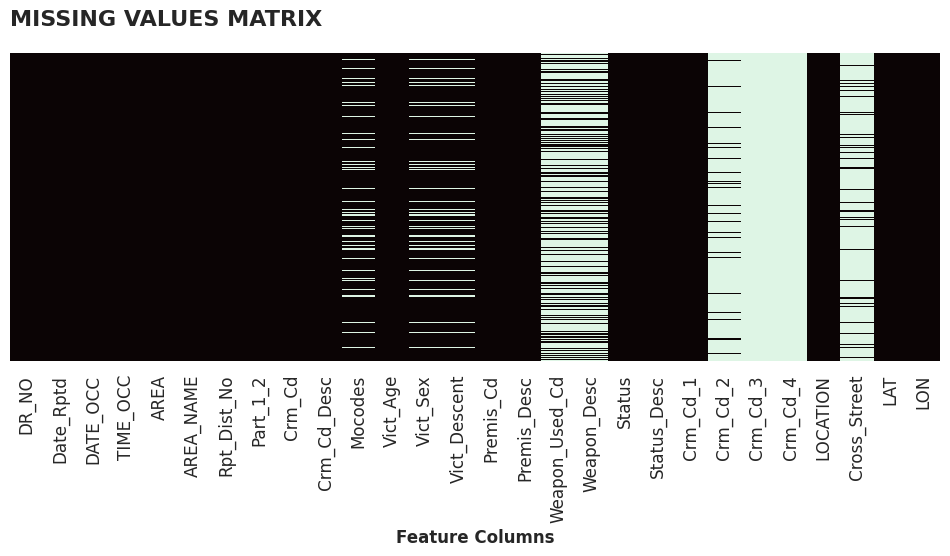

Top columns with missing values:
Crm_Cd_4          99.993374
Crm_Cd_3          99.760144
Crm_Cd_2          92.767221
Cross_Street      83.834248
Weapon_Used_Cd    65.659537
dtype: float64




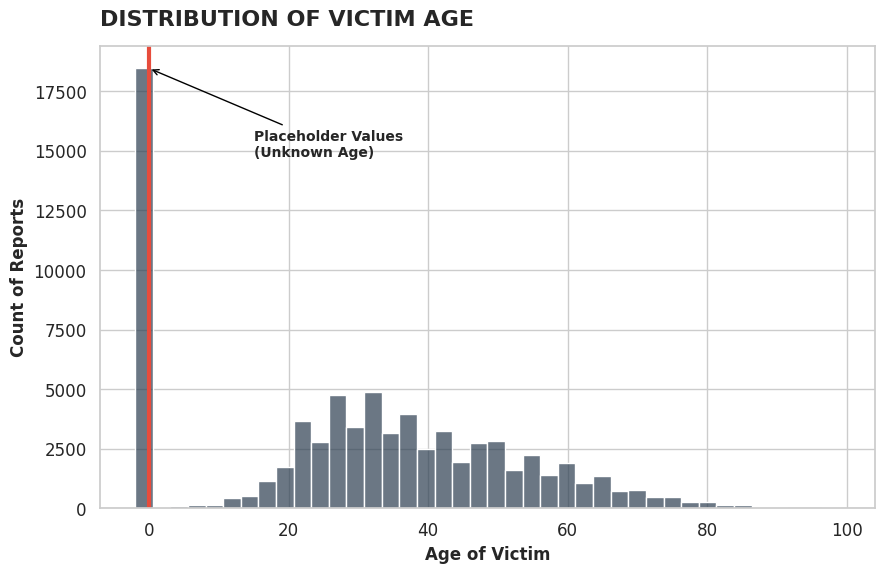

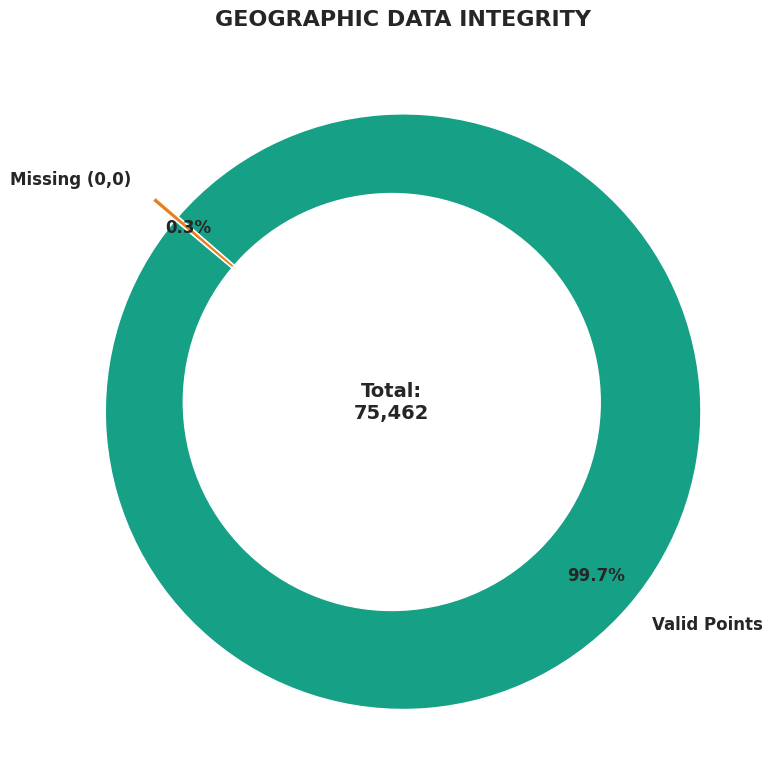

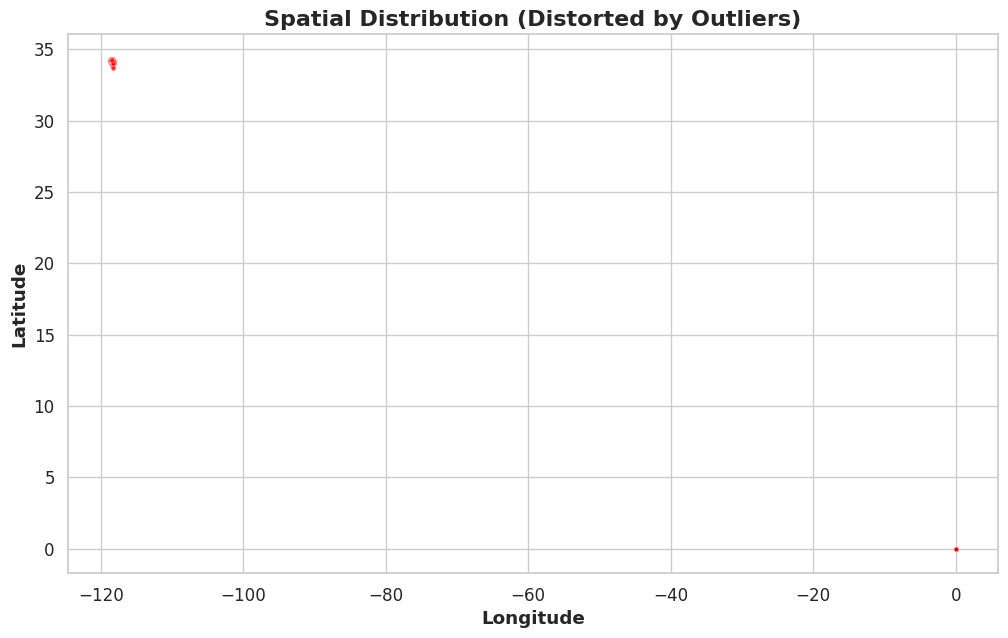

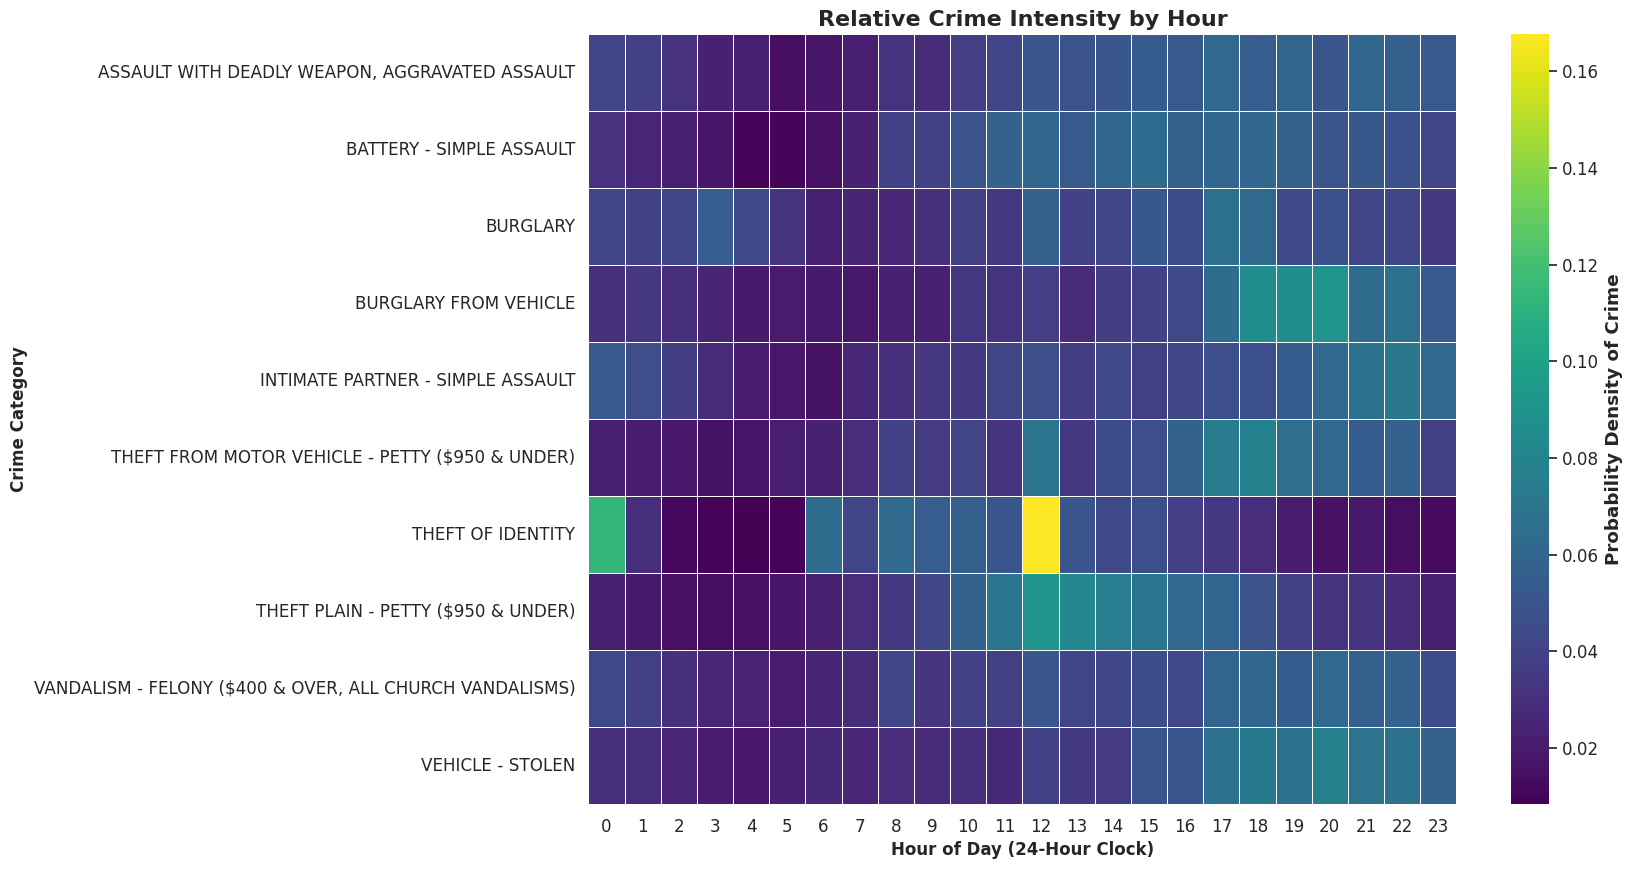

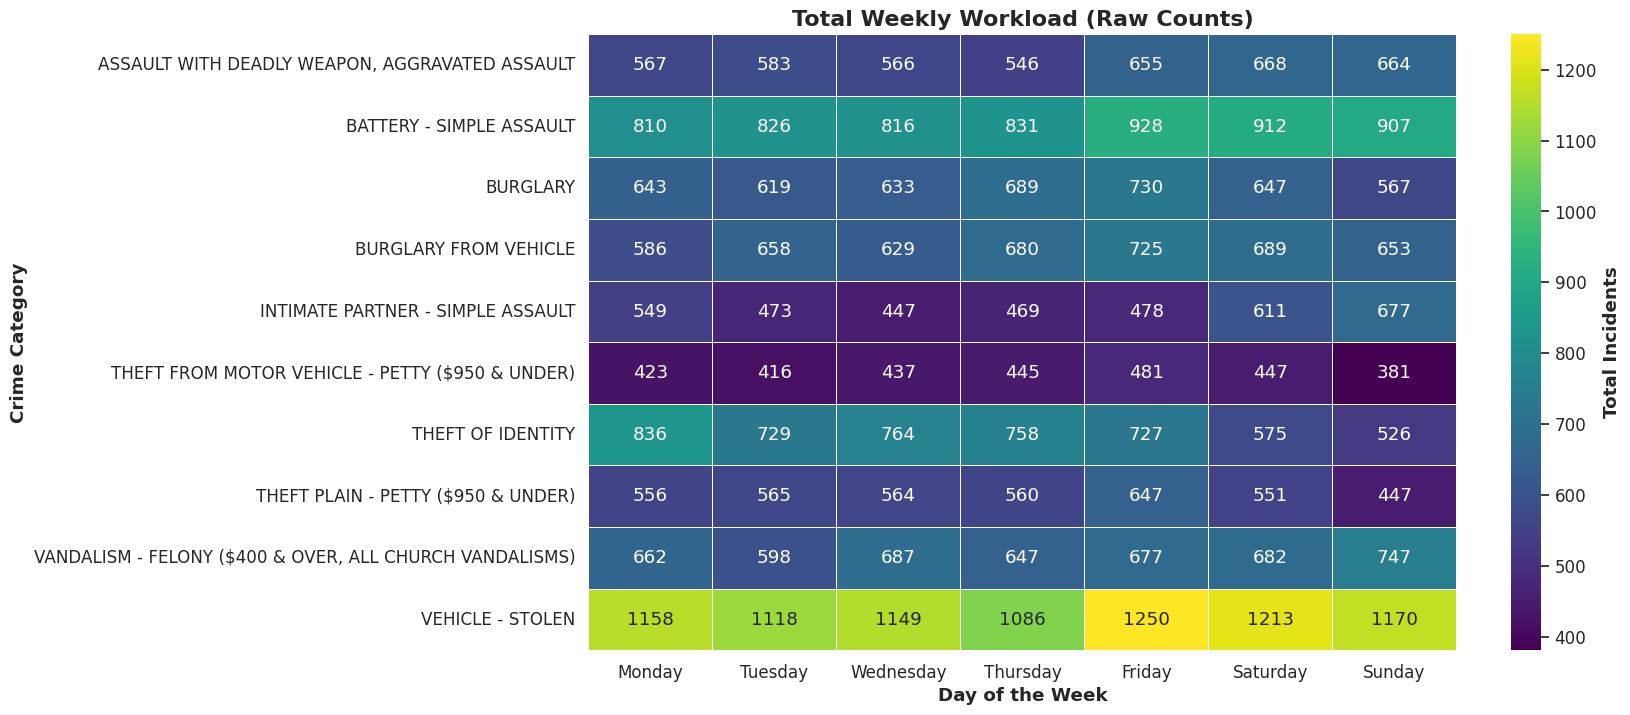

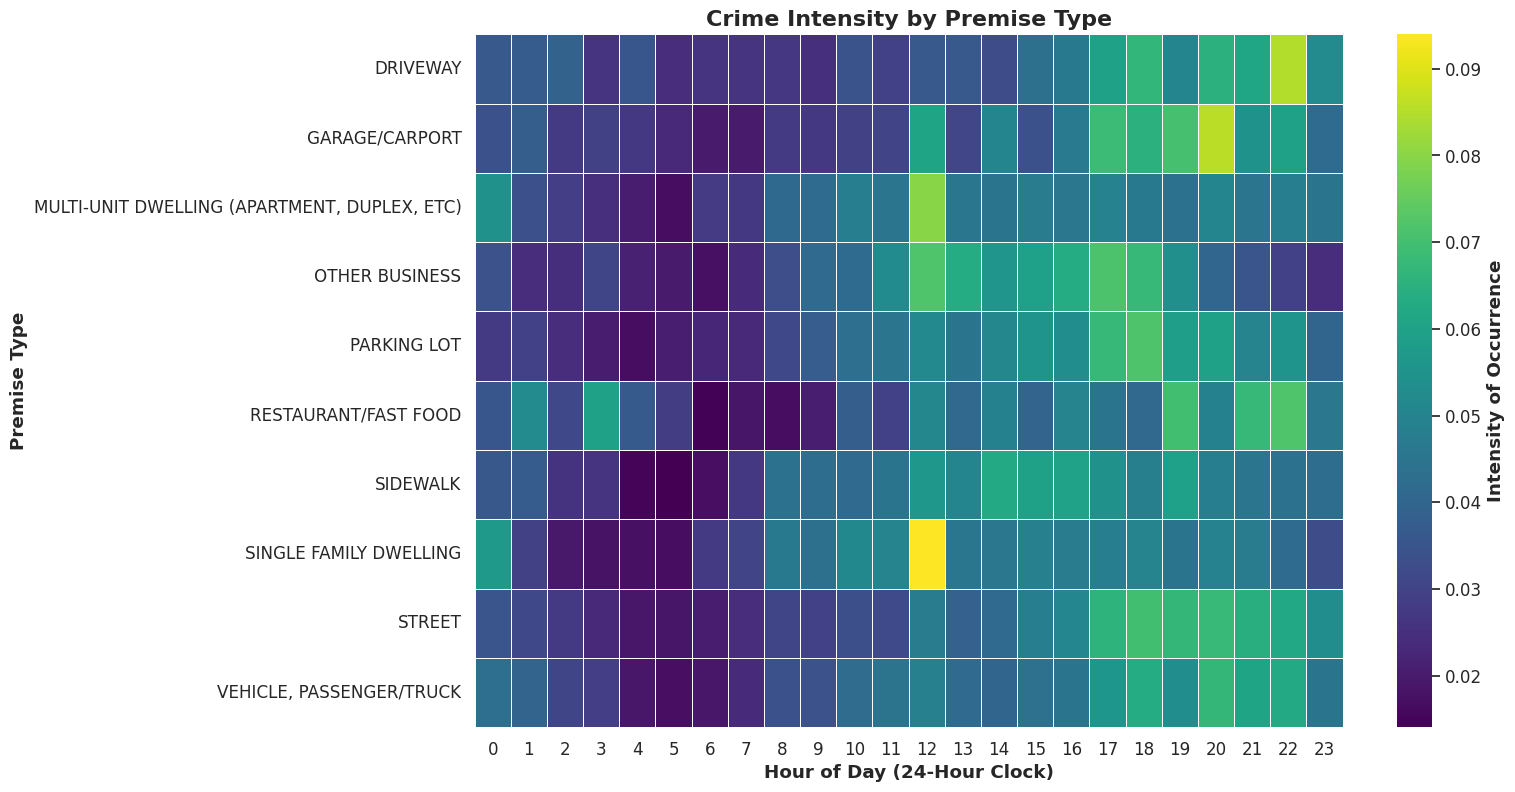

In [ ]:
# BEFORE PRE-PROCESSING OF DATASET
# NO CLEANING MODIFICATIONS YET ON DATA

import pandas as pd

#Converting Spark Dataframe to Panda Dataframe to better support Seaborn
#Downsampled to not consume too much space
df_eda1 = raw_df.sample(fraction=0.1, seed=42).toPandas()

### IDENTIFYING DATA QUALITY ISSUES ###

# MISSING VALUES
missing_pct = df_eda1.isnull().mean() * 100

plt.figure(figsize=(12, 4))
sns.heatmap(df_eda1.isnull(), cbar=False, yticklabels=False, cmap='mako')

plt.title('MISSING VALUES MATRIX', loc='left', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Feature Columns', fontsize=12)
plt.show()

print(f"Top columns with missing values:\n{missing_pct.nlargest(5)}")

print("\n" + "="*200 + "\n")

# USING 0 & NEGATIVE NUMBERS AS PLACEHOLDERS FOR UNKNOWN VICTIM AGE
plt.figure(figsize=(10, 6))

# Plotting the distribution to expose the '0' age spike
sns.histplot(df_eda1['Vict_Age'], bins=40, kde=False, color='#2C3E50', alpha=0.7, edgecolor='white')

# Adding a vertical line to highlight the placeholder issue
plt.axvline(x=0, color='#E74C3C', linestyle='-', linewidth=3, label='Recording Artifact (Age 0)')

plt.annotate('Placeholder Values\n(Unknown Age)', xy=(0, df_eda1[df_eda1['Vict_Age']==0].shape[0]),
             xytext=(15, df_eda1[df_eda1['Vict_Age']==0].shape[0] * 0.8),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10, fontweight='bold')

plt.title('DISTRIBUTION OF VICTIM AGE', loc='left', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age of Victim', fontsize=12)
plt.ylabel('Count of Reports', fontsize=12)
plt.show()

print("\n" + "="*200 + "\n")

# (0,0) COORDINATES IN LAT / LON
# Identify invalid coordinates
invalid_coords = df_eda1[(df_eda1['LAT'] == 0) | (df_eda1['LON'] == 0)]
valid_coords = df_eda1[(df_eda1['LAT'] != 0) & (df_eda1['LON'] != 0)]

plt.figure(figsize=(8, 8))

sizes = [len(valid_coords), len(invalid_coords)]
labels = ['Valid Points', 'Missing (0,0)']
colors = ['#16A085', '#E67E22']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, pctdistance=0.85, explode=(0.05, 0.05),
        textprops={'fontsize': 12, 'fontweight': 'bold'})
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.text(0, 0, f'Total:\n{len(df_eda1):,}', ha='center', va='center', fontsize=14, fontweight='bold')

plt.title('GEOGRAPHIC DATA INTEGRITY', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

print("\n" + "="*200 + "\n")

### DATA ANALYSIS (BEFORE PRE-PROCESSING) ###

# OBJECTIVE 1: SPACIAL CLUSTERING

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_eda1, x='LON', y='LAT', color='red', s=10, alpha=0.5)
plt.title('Spatial Distribution (Distorted by Outliers)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("\n" + "="*200 + "\n")

# OBJECTIVE 2: CRIME TRENDS OVER TIME

# Converting String to Datetime in Pandas
df_eda1['DATE_OCC'] = pd.to_datetime(
    df_eda1['DATE_OCC'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

# Extract features for EDA
df_eda1['Year'] = df_eda1['DATE_OCC'].dt.year
df_eda1['Month'] = df_eda1['DATE_OCC'].dt.month_name()
df_eda1['Day_of_Week'] = df_eda1['DATE_OCC'].dt.day_name()
df_eda1['Hour'] = df_eda1['TIME_OCC'] // 100

top_10_crimes = df_eda1['Crm_Cd_Desc'].value_counts().nlargest(10).index
df_ridge = df_eda1[df_eda1['Crm_Cd_Desc'].isin(top_10_crimes)]

# Crime Type vs. Hour

pivot_df = df_ridge.groupby(['Crm_Cd_Desc', 'Hour']).size().unstack(fill_value=0)

pivot_norm = pivot_df.div(pivot_df.sum(axis=1), axis=0)

plt.figure(figsize=(14, 10))

sns.heatmap(pivot_norm,
            cmap="viridis",
            annot=False,
            linewidths=.5,
            cbar_kws={'label': 'Probability Density of Crime'})

plt.title('Relative Crime Intensity by Hour', fontsize=16)
plt.xlabel('Hour of Day (24-Hour Clock)', fontsize=12)
plt.ylabel('Crime Category', fontsize=12)
plt.show()

# Crime Type vs. Day of Week

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_pivot = df_ridge.groupby(['Crm_Cd_Desc', 'Day_of_Week']).size().unstack(fill_value=0)
day_pivot = day_pivot.reindex(columns=days)

plt.figure(figsize=(14, 8))
sns.heatmap(day_pivot, cmap="viridis", annot=True, fmt="d", linewidths=.5,
            cbar_kws={'label': 'Total Incidents'})
plt.title('Total Weekly Workload (Raw Counts)')
plt.xlabel('Day of the Week')
plt.ylabel('Crime Category')
plt.show()


# Premise Type vs. Hour

top_10_premis = df_eda1['Premis_Desc'].value_counts().nlargest(10).index
df_premis = df_eda1[df_eda1['Premis_Desc'].isin(top_10_premis)]

premis_pivot = df_premis.groupby(['Premis_Desc', 'Hour']).size().unstack(fill_value=0)
premis_norm = premis_pivot.div(premis_pivot.sum(axis=1), axis=0)

plt.figure(figsize=(14, 9))
sns.heatmap(premis_norm, cmap="viridis", annot=False, linewidths=.5,
            cbar_kws={'label': 'Intensity of Occurrence'})
plt.title('Crime Intensity by Premise Type')
plt.xlabel('Hour of Day (24-Hour Clock)')
plt.ylabel('Premise Type')
plt.show()

**3.0 PRE-PROCESSING (DATA CLEANING)**


In [ ]:
# PREPROCESSING THE DATASET
print("\n------------\nBEFORE PREPROCESSING:")
print("COLS: ", len(raw_df.columns))
print("ROWS: ", raw_df.count(), "\n")
raw_df.show()

#3.1. OBJECTIVE 1: Dropping unnecessary columns.
clean_df = raw_df.drop("Part_1_2", "Mocodes", "Weapon_Used_Cd", "Weapon_Desc", "Crm_Cd_1", "Crm_Cd_2", "Crm_Cd_3", "Crm_Cd_4", "Cross_Street")

#3.2. OBJECTIVE 2: Ordering all rows ascedingly by "DR_NO", and removing null and duplicate values in the "DR_NO" column (if there's any).
clean_df = clean_df.orderBy(F.col("DR_NO").asc()).dropna(subset=["DR_NO"]).dropDuplicates(["DR_NO"])

#3.3. OBJECTIVE 3: Removing rows with "Vict_Age" <= 0, null "LON", and "LAT"values.
clean_df = clean_df.filter(F.col("Vict_Age") > 0).filter(F.col("LON") != 0).filter(F.col("LAT") != 0)

#3.4. OBJECTIVE 4: Ensuring all values are uniform , clean, and filled.
#3.4.1. Filling null values in the "Vict_Sex" and "Vict_Descent" columns with "x" to correspond to a "rather not say" option.
clean_df = clean_df.fillna("x", subset=["Vict_Sex", "Vict_Descent"])

#3.4.2. Converting all characters to lowercase and removing all trailing or leading spaces in each string (if there's any).
string_columns = ["AREA_NAME", "Crm_Cd_Desc", "Vict_Sex", "Vict_Descent", "Premis_Desc", "Status", "Status_Desc", "LOCATION"]
for c in string_columns:
    clean_df = clean_df.withColumn(c, F.lower(F.trim(c)))

#3.5. OBJECTIVE 5: Merging "DATE_OCC"'s date portions and their corresponding "TIME_OCC" values into a timestamp "DATETIME_OCC" column.
#3.5.1. Converting "DATE_OCC" values into timestamp format.
clean_df = clean_df.withColumn("DATE_OCC", F.to_timestamp("DATE_OCC", "MM/dd/yyyy hh:mm:ss a"))

#3.5.2. Puts only time-valid, zero-padded "TIME_OCC" values into a newly-added temporary "TIME_OCC_TEMP" string column.
clean_df = clean_df.withColumn(
    "TIME_OCC_TEMP", F.lpad(F.col("TIME_OCC").cast("string"), 4, "0")).filter(
    (F.substring("TIME_OCC_TEMP", 1, 2).cast("int") < 24) &
    (F.substring("TIME_OCC_TEMP", 3, 2).cast("int") < 60)
)

#3.5.3. Puts back all "TIME_OCC_TEMP" values into the now-tiemstamp column "DATE_OCC".
clean_df = clean_df.withColumn("TIME_OCC",F.to_timestamp("TIME_OCC_TEMP", "HHmm"))

#3.5.4. Merges each "DATE_OCC" and "TIME_OCC" part to their corresponding part in "DATETIME_OCC" values.
clean_df = clean_df.withColumn("DATETIME_OCC", F.expr("""
      make_timestamp(
          year(DATE_OCC), month(DATE_OCC), day(DATE_OCC),
          hour(TIME_OCC), minute(TIME_OCC), second(TIME_OCC)
      )""")
)

#3.5.5. Drops original "DATE_OCC" and "TIME_OCC" columns and the newly-added "TIME_OCC_TEMP" column.
clean_df = clean_df.drop("TIME_OCC_TEMP", "DATE_OCC", "TIME_OCC")

#Saving the preprocessed dataset by overwriting in a parquet file.
clean_df_file = "/content/drive/MyDrive/BIGD/preprocessed1_femb.parquet"
clean_df.write.mode("overwrite").parquet(clean_df_file)
print(f"\n------------\nPreprocessed dataset saved to: {clean_df_file}.\n")

print("\n------------\nAFTER PREPROCESSING:")
print("COLS: ", len(clean_df.columns))
print("ROWS: ", clean_df.count(), "\n")
clean_df.show()


------------
BEFORE PREPROCESSING:
COLS:  28
ROWS:  757141 

+---------+--------------------+--------------------+--------+----+-----------+-----------+--------+------+--------------------+--------------------+--------+--------+------------+---------+--------------------+--------------+--------------------+------+------------+--------+--------+--------+--------+--------------------+------------+-------+---------+
|    DR_NO|           Date_Rptd|            DATE_OCC|TIME_OCC|AREA|  AREA_NAME|Rpt_Dist_No|Part_1_2|Crm_Cd|         Crm_Cd_Desc|             Mocodes|Vict_Age|Vict_Sex|Vict_Descent|Premis_Cd|         Premis_Desc|Weapon_Used_Cd|         Weapon_Desc|Status| Status_Desc|Crm_Cd_1|Crm_Cd_2|Crm_Cd_3|Crm_Cd_4|            LOCATION|Cross_Street|    LAT|      LON|
+---------+--------------------+--------------------+--------+----+-----------+-----------+--------+------+--------------------+--------------------+--------+--------+------------+---------+--------------------+--------------+

**4.0 EDA (AFTER PRE-PROCESSING)**


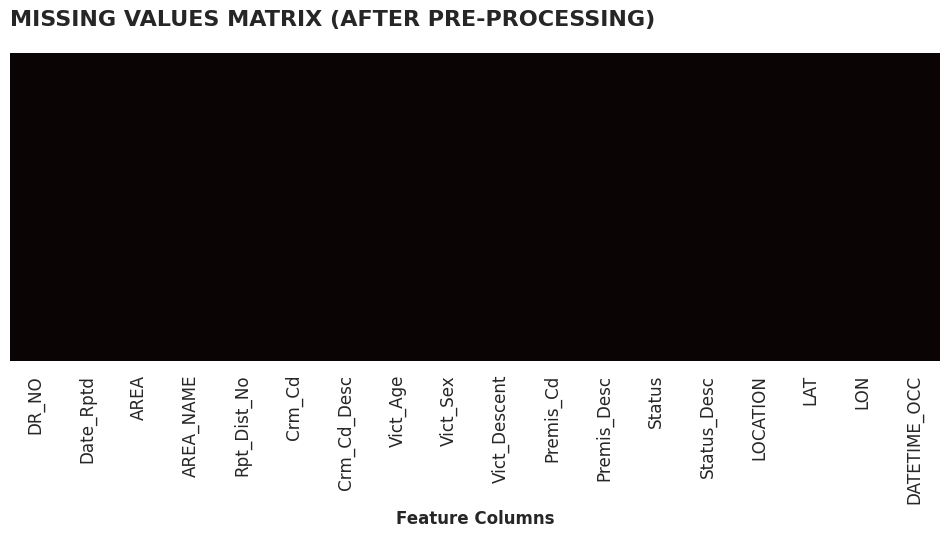

Top columns with missing values:
Premis_Desc    0.02806
DR_NO          0.00000
Date_Rptd      0.00000
AREA           0.00000
AREA_NAME      0.00000
dtype: float64




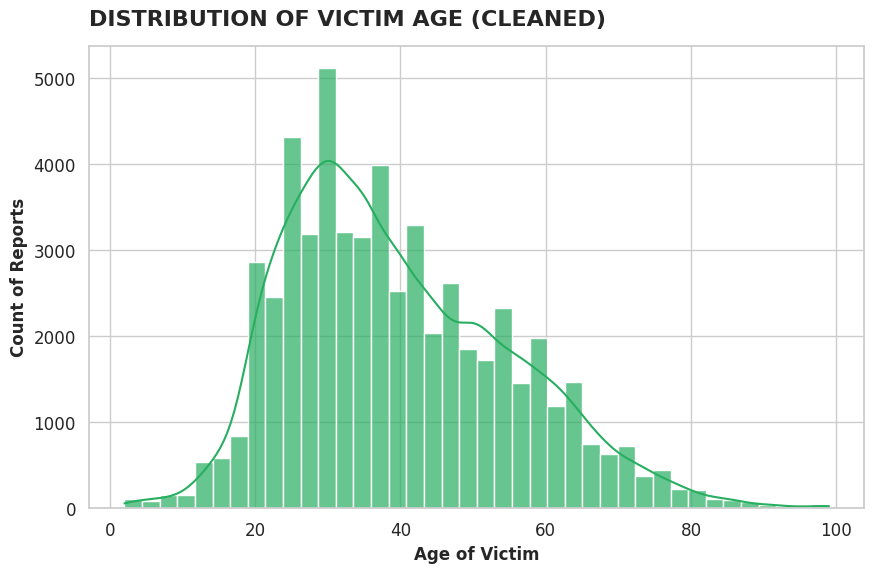

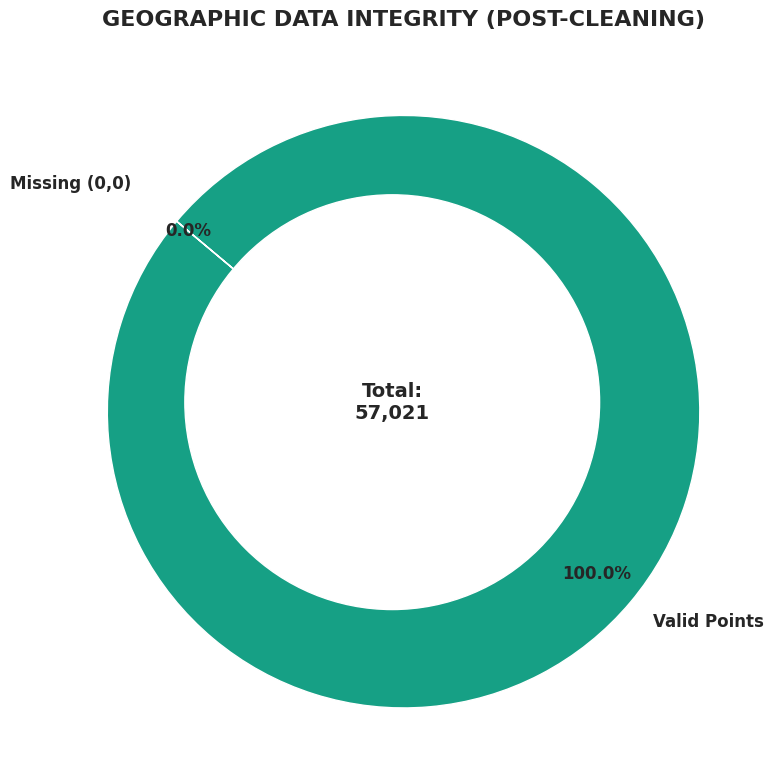

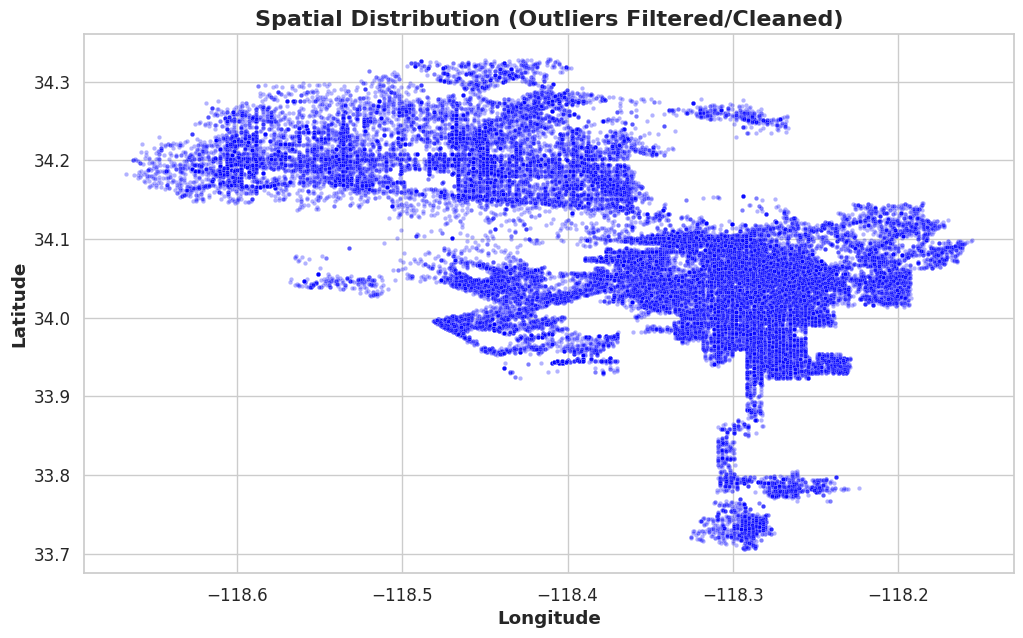

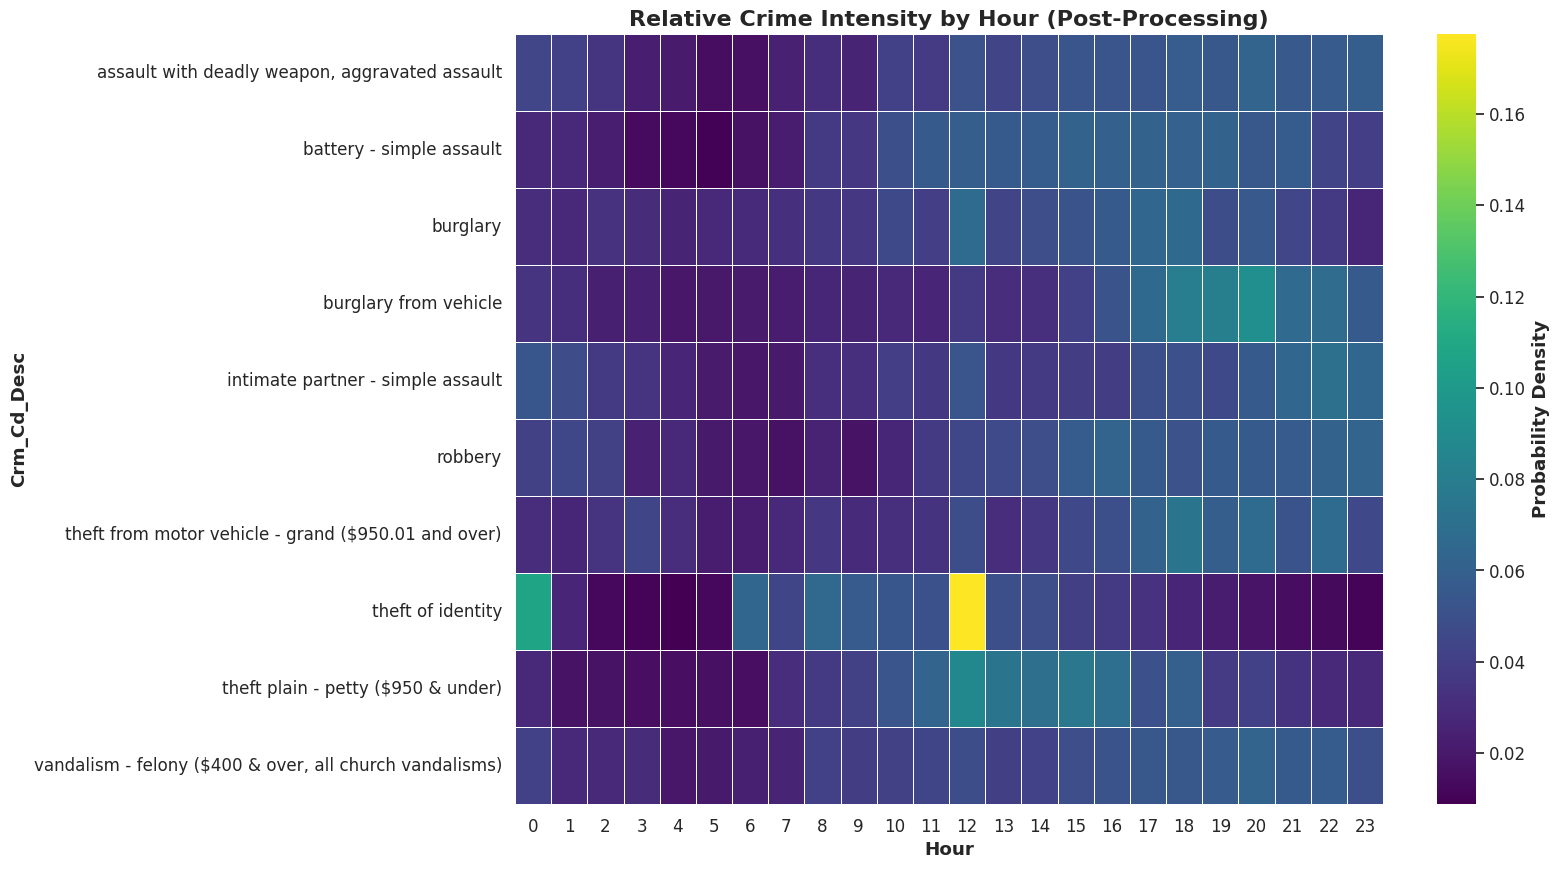

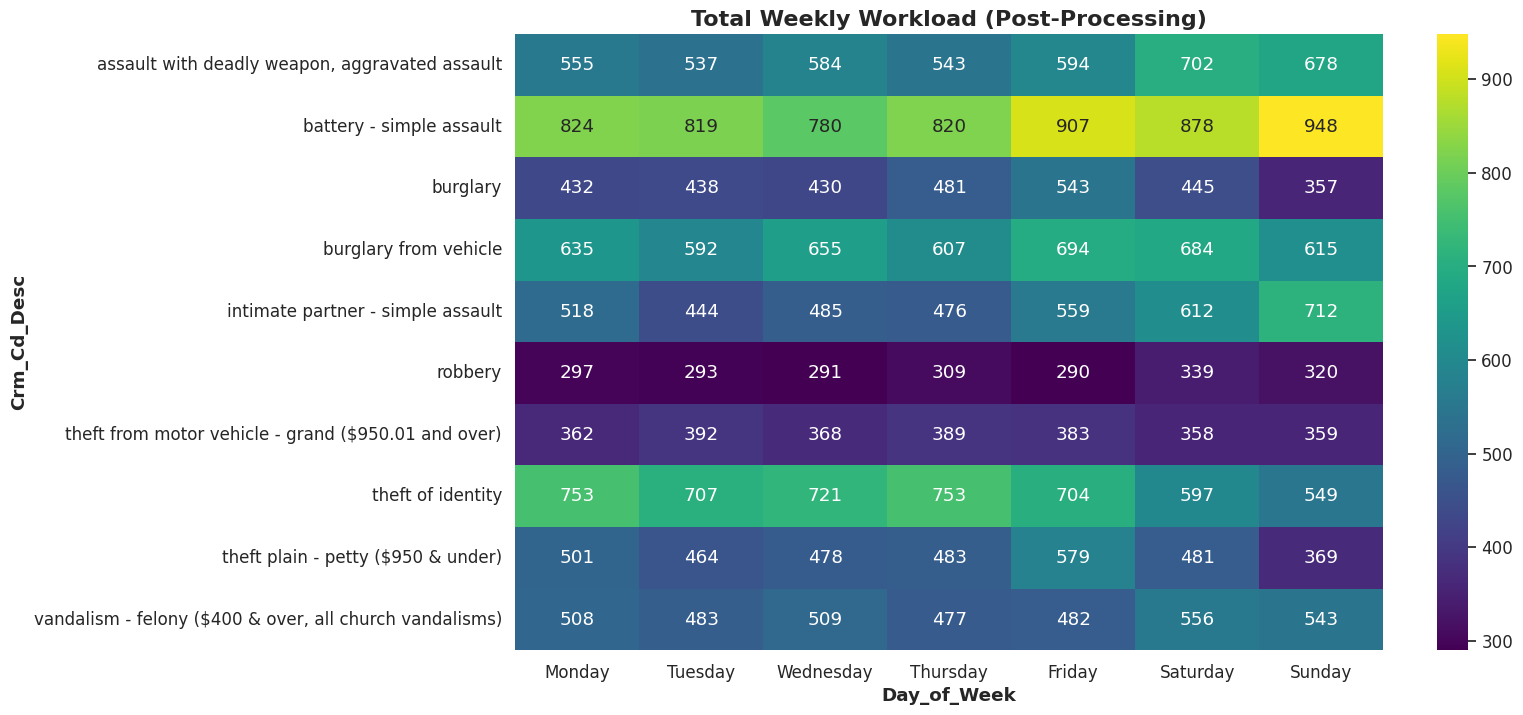

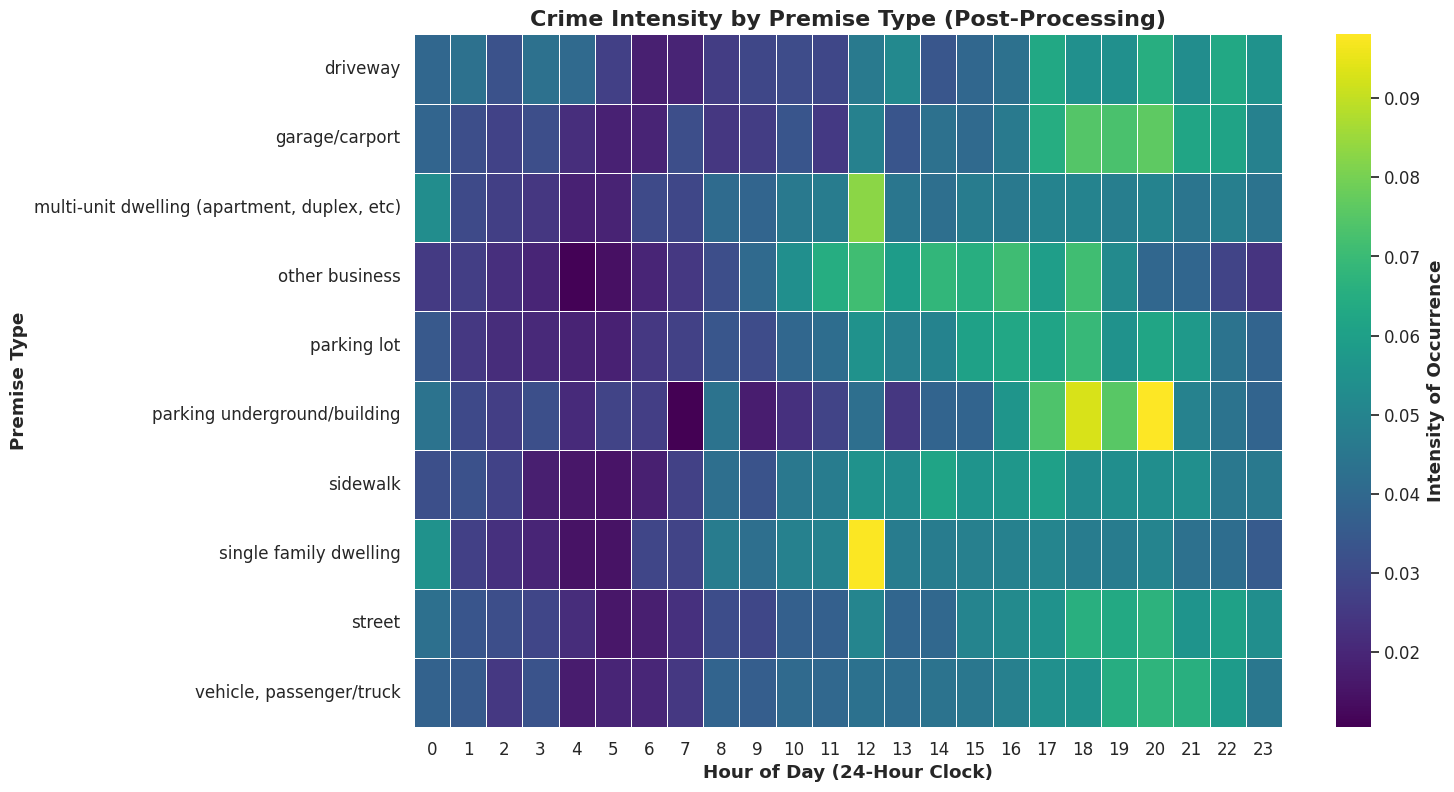

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOADING THE PREPROCESSED DATASET
clean_df_file = "/content/drive/MyDrive/BIGD/preprocessed1_femb.parquet"
df_after = spark.read.parquet(clean_df_file)

#CONVERTING SPARK DATAFRAME TO PANDA DATAFRAME FOR VISUALIZATION (sampling 10%)
df_eda2 = df_after.sample(fraction=0.1, seed=42).toPandas()

#STEP1. MISSING VALUUES MATRIX (POST-CLEANING)
plt.figure(figsize=(12, 4))
sns.heatmap(df_eda2.isnull(), cbar=False, yticklabels=False, cmap='mako')
plt.title('MISSING VALUES MATRIX (AFTER PRE-PROCESSING)', loc='left', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Feature Columns', fontsize=12)
plt.show()

missing_pct_after = df_eda2.isnull().mean() * 100
print(f"Top columns with missing values:\n{missing_pct_after.nlargest(5)}")
print("\n" + "="*200 + "\n")

#STEP2. DISTRIBUTION OF VICTIM AGE (POST-CLEANING)
plt.figure(figsize=(10, 6))
sns.histplot(df_eda2['Vict_Age'], bins=40, kde=True, color='#27AE60', alpha=0.7, edgecolor='white')
plt.title('DISTRIBUTION OF VICTIM AGE (CLEANED)', loc='left', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age of Victim', fontsize=12)
plt.ylabel('Count of Reports', fontsize=12)
plt.show()
print("\n" + "="*200 + "\n")

#STEP3. GEOGRAPHIC DATA INTEGRITY (POST-CLEANING)
invalid_coords = df_eda2[(df_eda2['LAT'] == 0) | (df_eda2['LON'] == 0)]
valid_coords = df_eda2[(df_eda2['LAT'] != 0) & (df_eda2['LON'] != 0)]

plt.figure(figsize=(8, 8))
sizes = [len(valid_coords), len(invalid_coords)]
labels = ['Valid Points', 'Missing (0,0)']
colors = ['#16A085', '#E67E22']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, pctdistance=0.85, explode=(0.05, 0.05),
        textprops={'fontsize': 12, 'fontweight': 'bold'})
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.text(0, 0, f'Total:\n{len(df_eda2):,}', ha='center', va='center', fontsize=14, fontweight='bold')
plt.title('GEOGRAPHIC DATA INTEGRITY (POST-CLEANING)', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()
print("\n" + "="*200 + "\n")

#STEP4. SPATIAL DISTRIBUTION (POST-CLEANING)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_eda2[df_eda2['LAT'] != 0], x='LON', y='LAT', color='blue', s=10, alpha=0.3)
plt.title('Spatial Distribution (Outliers Filtered/Cleaned)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
print("\n" + "="*200 + "\n")

#STEP5. CRIME TRENDS OVER TIME (POST-CLEANING)
df_eda2['Year'] = df_eda2['DATETIME_OCC'].dt.year
df_eda2['Month'] = df_eda2['DATETIME_OCC'].dt.month_name()
df_eda2['Day_of_Week'] = df_eda2['DATETIME_OCC'].dt.day_name()
df_eda2['Hour'] = df_eda2['DATETIME_OCC'].dt.hour

top_10_crimes = df_eda2['Crm_Cd_Desc'].value_counts().nlargest(10).index
df_ridge = df_eda2[df_eda2['Crm_Cd_Desc'].isin(top_10_crimes)]

#Crime Type vs. Hour Heatmap
pivot_df = df_ridge.groupby(['Crm_Cd_Desc', 'Hour']).size().unstack(fill_value=0)
pivot_norm = pivot_df.div(pivot_df.sum(axis=1), axis=0)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_norm, cmap="viridis", linewidths=.5, cbar_kws={'label': 'Probability Density'})
plt.title('Relative Crime Intensity by Hour (Post-Processing)', fontsize=16)
plt.show()
print("\n" + "="*200 + "\n")

#Crime Type vs. Day of Week
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_pivot = df_ridge.groupby(['Crm_Cd_Desc', 'Day_of_Week']).size().unstack(fill_value=0).reindex(columns=days)

plt.figure(figsize=(14, 8))
sns.heatmap(day_pivot, cmap="viridis", annot=True, fmt="d")
plt.title('Total Weekly Workload (Post-Processing)')
plt.show()
print("\n" + "="*200 + "\n")

# Premise Type vs. Hour
top_10_premis = df_eda2['Premis_Desc'].value_counts().nlargest(10).index
df_premis = df_eda2[df_eda2['Premis_Desc'].isin(top_10_premis)]

premis_pivot = df_premis.groupby(['Premis_Desc', 'Hour']).size().unstack(fill_value=0)
premis_norm = premis_pivot.div(premis_pivot.sum(axis=1), axis=0)

plt.figure(figsize=(14, 9))
sns.heatmap(premis_norm, cmap="viridis", annot=False, linewidths=.5,
            cbar_kws={'label': 'Intensity of Occurrence'})
plt.title('Crime Intensity by Premise Type (Post-Processing)')
plt.xlabel('Hour of Day (24-Hour Clock)')
plt.ylabel('Premise Type')
plt.show()